# Simulations of effective dose on a surface


Effective dose is used to assess the potential for long-term radiation effects that might occur in the future.

Effective dose provides a single number that reflects the exposure to radiation. To quote ICRP who define the quantity, "it sums up any number of different exposures into a single number that reflects, in a general way, the overall risk".

Effective dose is a calculated value, measured in mSv. Effective dose is calculated for the whole body. It is the sum of equivalent doses to all organs, each adjusted to account for the sensitivity of the organ to radiation. Read more about equivalent dose, absorbed dose and effective dose on the ICRP website.

http://icrpaedia.org/Absorbed,_Equivalent,_and_Effective_Dose

The effective dose deposited by a neutron or photon depends on the energy of the particle. The dose coefficients provided by ICRP are energy dependant.

The following section plots effective dose coefficient as a function of incident particle energy for neutrons and photons.

First import packages needed and configure the OpenMC nuclear data path

In [1]:
import plotly.graph_objects as go
import openmc
from pathlib import Path
# Setting the cross section path to the correct location in the docker image.
# If you are running this outside the docker image you will have to change this path to your local cross section path.
openmc.config['cross_sections'] = Path.home() / 'nuclear_data' / 'cross_sections.xml'

In [2]:
energy_bins_n, dose_coeffs_n = openmc.data.dose_coefficients(
    particle='neutron',
    geometry='AP'  # AP defines the direction of the source to person, for more details see documentation https://docs.openmc.org/en/stable/pythonapi/generated/openmc.data.dose_coefficients.html
)

energy_bins_p, dose_coeffs_p = openmc.data.dose_coefficients(particle='photon', geometry='AP')

fig = go.Figure()

fig.update_layout(
      title='ICRP Effective Dose Coefficient (AP)',
      xaxis={'title': 'Energy (eV)',
             'range': (0, 14.1e6)},
      yaxis={'title': 'Effective dose per fluence, in units of pSv cm²'}
)


fig.add_trace(go.Scatter(
    x=energy_bins_p,
    y=dose_coeffs_p,
    mode='lines',
    name='photon'
))

fig.add_trace(go.Scatter(
    x=energy_bins_n,
    y=dose_coeffs_n,
    mode='lines',
    name='neutron'
))

To find the effective dose on a surface a geometry is needed along with some materials and a tally.

The following section makes a 'cask' geometry and materials which will have a dose tally added to it later.

This code block makes the material used for the cask.

In [3]:
steel = openmc.Material()
steel.set_density('g/cm3', 7.75)
steel.add_element('Fe', 0.95, percent_type='wo')
steel.add_element('C', 0.05, percent_type='wo')

my_materials = openmc.Materials([steel])

This code block makes the CSG geometry for the cask.

In [4]:
height = 100
outer_radius = 50
thickness = 10

outer_cylinder = openmc.ZCylinder(r=outer_radius)
inner_cylinder = openmc.ZCylinder(r=outer_radius-thickness)
inner_top = openmc.ZPlane(z0=height*0.5)
inner_bottom = openmc.ZPlane(z0=-height*0.5)
outer_top = openmc.ZPlane(z0=(height*0.5)+thickness)
outer_bottom = openmc.ZPlane(z0=(-height*0.5)-thickness)

# this shpere_1 are used to tally the dose
sphere_1 = openmc.Sphere(r=100)
# can't actually tally on the end of universe sphere hence sphere 1 is needed
sphere_2 = openmc.Sphere(r=101, boundary_type='vacuum')

cylinder_region = -outer_cylinder & +inner_cylinder & -inner_top & +inner_bottom
cylinder_cell = openmc.Cell(region=cylinder_region)
cylinder_cell.fill = steel

top_cap_region = -outer_top & +inner_top & -outer_cylinder
top_cap_cell = openmc.Cell(region=top_cap_region)
top_cap_cell.fill = steel

bottom_cap_region = +outer_bottom & -inner_bottom & -outer_cylinder
bottom_cap_cell = openmc.Cell(region=bottom_cap_region)
bottom_cap_cell.fill = steel

inner_void_region = -inner_cylinder & -inner_top & +inner_bottom
inner_void_cell = openmc.Cell(region=inner_void_region)

# sphere 1 region is below -sphere_1 and not (~) in the other regions
sphere_1_region = -sphere_1
sphere_1_cell = openmc.Cell(
    region= sphere_1_region
    & ~bottom_cap_region
    & ~top_cap_region
    & ~cylinder_region
    & ~inner_void_region
)

sphere_2_region = +sphere_1 & -sphere_2
sphere_2_cell = openmc.Cell(region= sphere_2_region)

my_geometry = openmc.Geometry([
    inner_void_cell, cylinder_cell, top_cap_cell,
    bottom_cap_cell, sphere_1_cell, sphere_2_cell])

This code block plots the geometry and colours regions to identify the cells / materials - useful for checking the geometry looks correct.

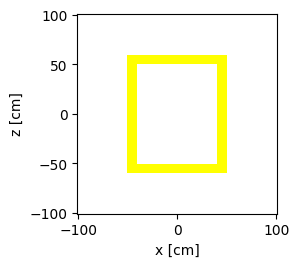

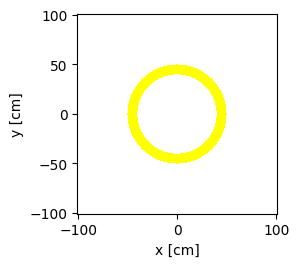

In [5]:
import matplotlib.pyplot as plt
color_assignment = {sphere_1_cell: 'grey',
                    sphere_2_cell: 'grey',
                    inner_void_cell: 'grey',
                    bottom_cap_cell: 'red',
                    top_cap_cell: 'blue',
                    cylinder_cell:'yellow',
                   }
x, y = 200, 200
plot = my_geometry.plot(basis='xz', color_by='material', colors=color_assignment) 
plot.figure.savefig('xz.png')

plot = my_geometry.plot(basis='xy', color_by='material', colors=color_assignment) 
plot.figure.savefig('xy.png')

This section makes the source. Note the use of the Co60 gamma source with two energy levels.

In [6]:
# Instantiate a Settings object
my_settings = openmc.Settings()
my_settings.batches = 10
my_settings.inactive = 0
my_settings.particles = 500
my_settings.run_mode = 'fixed source'

# Create a gamma point source
my_source = openmc.IndependentSource()
my_source.space = openmc.stats.Point((0, 0, 0))
my_source.angle = openmc.stats.Isotropic()
# This is a Co60 source, see the task on sources to understand it
my_source.energy = openmc.stats.Discrete([1.1732e6,1.3325e6], [0.5, 0.5])
my_source.particle = 'photon'
my_settings.source = my_source

Dose coefficients can then be used in a neutronics tally with the openmc.EnergyFunctionFilter.

This will multiply the particle energy spectra with the effective dose coefficient to produce a single number for effective dose.

ICRP recommend the use of 'cubic' interpolation.
"For interpolations of absorbed dose and effective dose per fluence, a four-point (cubic) Lagrangian interpolation formula is recommended, and alog–log graph scale is more appropriate. Interpolations of absorbed dose and effective dose per air kerma of photons should be carried out using a four-point(cubic) Lagrangian interpolation formula, and a linear–log graph scale is more appropriate." 
https://journals.sagepub.com/doi/pdf/10.1177/ANIB_40_2-5

In [7]:
energy_function_filter_n = openmc.EnergyFunctionFilter(energy_bins_n, dose_coeffs_n)
energy_function_filter_n.interpolation = 'cubic'  # cubic interpolation is recommended by ICRP

energy_function_filter_p = openmc.EnergyFunctionFilter(energy_bins_p, dose_coeffs_p)
energy_function_filter_p.interpolation = 'cubic'  # cubic interpolation is recommended by ICRP

photon_particle_filter = openmc.ParticleFilter(["photon"])
surface_filter = openmc.SurfaceFilter(sphere_1)

dose_tally = openmc.Tally(name="dose_tally_on_surface")
dose_tally.scores = ["current"]
dose_tally.filters = [
    surface_filter,
    photon_particle_filter,
    energy_function_filter_p,
]
my_tallies = openmc.Tallies([dose_tally])

This code block runs the simulations.

In [8]:
# Run OpenMC!
model = openmc.model.Model(my_geometry, my_materials, my_settings, my_tallies)
!rm *.h5
sp_filename = model.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Reading Fe from /home/jon/nuclear_data/photon/Fe.h5 
 Reading Fe56 from /home/jon/nuclear_data/neutron/Fe56.h5


 Reading Fe57 from /home/jon/nuclear_data/neutron/Fe57.h5


 Reading Fe58 from /home/jon/nuclear_data/neutron/Fe58.h5


 Reading C12 from /home/jon/nuclear_data/neutron/C12.h5
 Reading C from /home/jon/nuclear_data/photon/C.h5 
 Reading C13 from /home/jon/nuclear_data/neutron/C13.h5
 Minimum neutron data temperature: 294.0 K
 Maximum neutron data temperature: 294.0 K
 Preparing distributed cell instances...
 Writing summary.h5 file...
 Maximum neutron transport energy: 20000000.0 eV for C13

 ===============>     FIXED SOURCE TRANSPORT SIMULATION     <===============

 Simulating batch 1
 Simulating batch 2
 Simulating batch 3
 Simulating batch 4
 Simulating batch 5
 Simulating batch 6
 Simulating batch 7
 Simulating batch 8
 Simulating batch 9
 Simulating batch 10
 Creating state point statepoint.10.h5...

 =======================>     TIMING STATISTICS     <=======================

 Total time for initialization     = 1.3979e+00 seconds
   Reading cross sections          = 1.3750e+00 seconds
 Total time in simulation          = 4.4274e-02 seconds
   Time in transport only          = 3.2830e-02 seconds

The following section extracts the tally result of the simulation and post-processes it to calculate the dose rate.

The cell tally has units of pSv cm² per source particle (p is pico). Therefore, the tally result must be divided by the surface area of the sphere to make the units into pSv, and then multiplied by the activity (in Bq) of the source to get pSv per second.

In [9]:
import math

# open the results file
sp = openmc.StatePoint(sp_filename)

# access the tally using pandas dataframes
tally = sp.get_tally(name='dose_tally_on_surface')
df = tally.get_pandas_dataframe()

tally_result = df['mean'].sum()
tally_std_dev = df['std. dev.'].sum()

# convert from the tally output units of pSv cm² to pSv by dividing by the surface area of the surface
dose_in_pSv = tally_result / (4 * math.pi * math.pow(200, 2))

source_activity = 56000  # in decays per second (Bq)
emission_rate = 2  # the number of gammas emitted per decay which is approximately 2 for Co60
gamma_per_second = source_activity * emission_rate
dose_rate_in_pSv = dose_in_pSv * gamma_per_second

# print results
print('The surface dose = ', dose_rate_in_pSv, 'pico Sv per second')

The surface dose =  0.042693937968328384 pico Sv per second


**Learning Outcomes for Part 1:**

- Appreciation of equivalent and effective dose.
- Dose tallies.
- Post-processing of tally results to obtain dose rate.